<h1 style="color:black;text-align:center;font-size:300%;font-family:verdana;">
DBSCAN
</h1>

# 🎬 Clustering Movies with DBSCAN

This analysis uses the **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** algorithm to uncover natural groupings in movie data from the TMDb dataset.   
Unlike k-means, DBSCAN does not require predefining the number of clusters and is well-suited for identifying arbitrarily shaped **clusters** and **outliers** (e.g., unusually short, low-rated, or high-performing movies).

## 🎯 Objective

The goal is to explore natural clusters in the movie landscape — from blockbuster hits to niche indie films — using a purely data-driven, unsupervised learning approach.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import davies_bouldin_score

from sklearn.decomposition import PCA

import warnings
warnings.simplefilter(action='ignore')

In [189]:
df = pd.read_csv('tmdb_movies_cleaned.csv')

In [190]:
df.head()

,id,title,runtime,release_date,budget,revenue,popularity,vote_average,vote_count,belongs_to_collection,...,main_production_country,num_production_countries,num_spoken_languages,is_english_spoken,popularity_percentile,weighted_rating,release_year,season,return_on_investment_ratio,profit_or_loss
0,5,Four Rooms,98,1995-12-09,4000000,4257354,6.08,5.90,2687,0,...,United States of America,1,1,True,79.50,5.92,1995,Winter,0.06,257354
1,6,Judgment Night,109,1993-10-15,21000000,12136938,3.15,6.46,349,0,...,United States of America,1,1,True,52.87,6.43,1993,Fall,-0.42,-8863062
2,11,Star Wars,121,1977-05-25,11000000,775398007,49.07,8.20,21079,1,...,United States of America,1,1,True,99.69,8.19,1977,Spring,69.49,764398007
3,12,Finding Nemo,100,2003-05-30,94000000,940335536,19.01,7.82,19605,1,...,United States of America,1,1,True,98.03,7.81,2003,Spring,9.00,846335536
4,13,Forrest Gump,142,1994-06-23,55000000,677387716,26.91,8.47,28122,0,...,United States of America,1,1,True,99.04,8.46,1994,Summer,11.32,622387716


In [191]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9953 entries, 0 to 9952
Data columns (total 46 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          9953 non-null   int64  
 1   title                       9953 non-null   object 
 2   runtime                     9953 non-null   int64  
 3   release_date                9953 non-null   object 
 4   budget                      9953 non-null   int64  
 5   revenue                     9953 non-null   int64  
 6   popularity                  9953 non-null   float64
 7   vote_average                9953 non-null   float64
 8   vote_count                  9953 non-null   int64  
 9   belongs_to_collection       9953 non-null   int64  
 10  has_tagline                 9953 non-null   int64  
 11  has_homepage                9953 non-null   int64  
 12  num_same_title              9953 non-null   int64  
 13  changed_title               9953 

## 🔍 Feature Selection

- DBSCAN works with numerical features only.
- It clusters based on distances, so scaling is important.
- It can capture arbitrary-shaped clusters but doesn’t work well with high-dimensional - low density features.
___

In [192]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
print(numeric_df.columns.tolist())

['id', 'runtime', 'budget', 'revenue', 'popularity', 'vote_average', 'vote_count', 'belongs_to_collection', 'has_tagline', 'has_homepage', 'num_same_title', 'num_genres', 'num_production_companies', 'num_production_countries', 'num_spoken_languages', 'popularity_percentile', 'weighted_rating', 'release_year', 'return_on_investment_ratio', 'profit_or_loss']


In [193]:
bool_df = df.select_dtypes(include=['bool'])
print(bool_df.columns.tolist())

['changed_title', 'Comedy', 'Action', 'Animation', 'Drama', 'History', 'Family', 'War', 'Thriller', 'Crime', 'Adventure', 'Music', 'Fantasy', 'Science Fiction', 'TV Movie', 'Western', 'Documentary', 'Romance', 'Mystery', 'Horror', 'top10_prod_comps', 'is_english_spoken']


### Due to DBSCAN being highly sensetive to distance metrics, boolean features (consisting of only 0 or 1 values) are not the best candidates for quality clustering with this algorithm.
* Note - We can use these features if we handle them correctly, but due to the fact that we have so many features to chose from, we have decided not to currently use these features.

In [194]:
# drop non-relevant and bool columns
numeric_df = numeric_df.drop(columns=['id', 'belongs_to_collection', 'has_tagline', 'has_homepage'])
print(f"Number of numeric features after dropping non-relevant columns: {numeric_df.shape[1]}")

Number of numeric features after dropping non-relevant columns: 16


In [195]:
numeric_df.columns

Index(['runtime', 'budget', 'revenue', 'popularity', 'vote_average',
       'vote_count', 'num_same_title', 'num_genres',
       'num_production_companies', 'num_production_countries',
       'num_spoken_languages', 'popularity_percentile', 'weighted_rating',
       'release_year', 'return_on_investment_ratio', 'profit_or_loss'],
      dtype='object')

## 📁 Organizing Relevant Data
1. Highly Correlated Features Cause Redundancy:
   - Features that are strongly correlated don't add new information, however they do **distort distance calculations**, since their impact is calculated **twice**.
   - This can lead to DBSCAN clustering based on those features alone, ignoring others.
   - Fix: We can keep just one of any strongly correlated pair - even better if we have a feature that consists of both.
   - We should check highly correlated features seperately first.
2. Highly Skewed Features Dominate Distance:
   - Extremely skewed features can **introduce outliers** or **compress distances** between points even after scalling.
   - This can cause inconsistent clusters or classify everything as noise.
   - Fix: Use log transforms or percentiles to even skewness or drop overly skewed features if they don't help with cluster seperation.
___


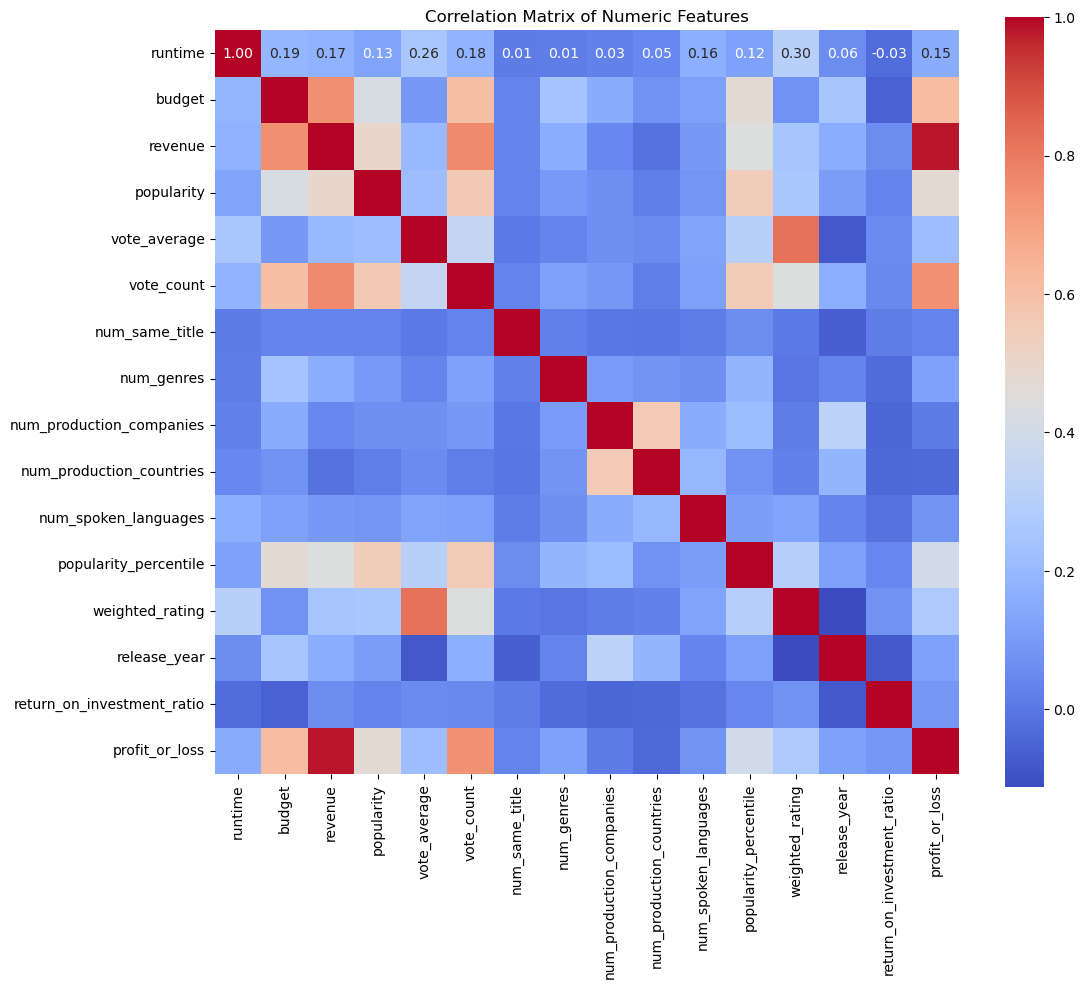

In [196]:
numeric_correlation = numeric_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_correlation, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [197]:
numeric_skewness = numeric_df.skew().sort_values(ascending=True)
print("Skewness of numeric features:")
print(numeric_skewness.round(2))

Skewness of numeric features:
release_year                 -1.66
vote_average                 -0.64
popularity_percentile         0.00
weighted_rating               0.22
num_genres                    0.49
runtime                       1.13
num_production_companies      1.86
num_spoken_languages          2.73
num_production_countries      3.04
budget                        3.40
vote_count                    4.05
num_same_title                5.10
revenue                       6.02
profit_or_loss                6.69
popularity                   19.62
return_on_investment_ratio   22.29
dtype: float64


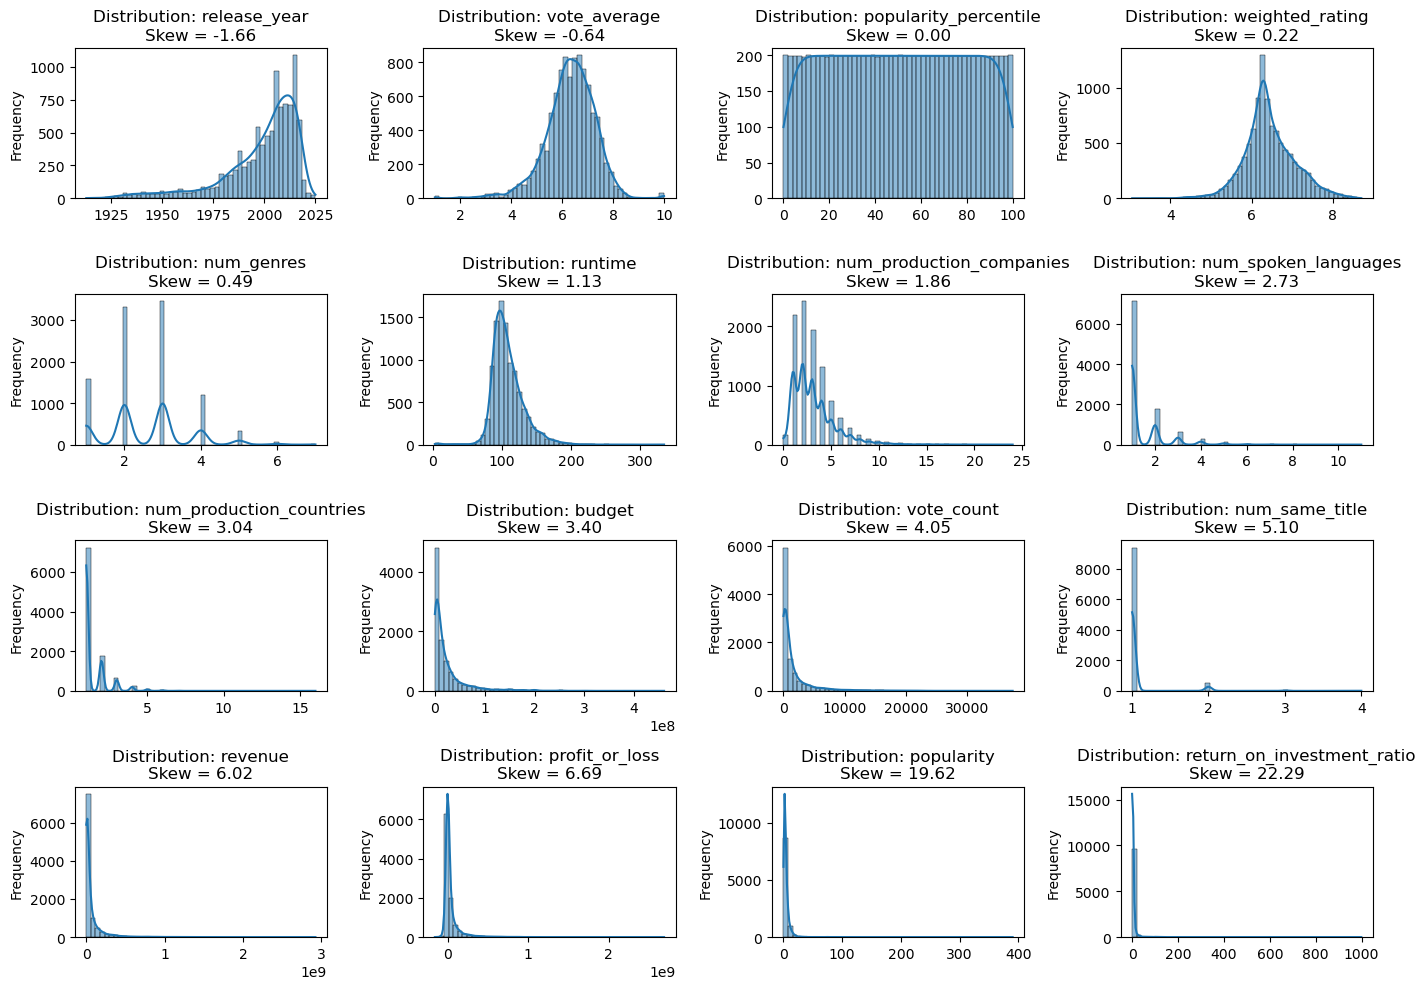

In [198]:
plt.figure(figsize=(14, 10))
for i, feature in enumerate(numeric_skewness.index[:16]):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[feature], bins=50, kde=True)
    plt.title(f'Distribution: {feature}\nSkew = {numeric_skewness[feature]:.2f}')
    plt.xlabel('')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### `vote_count` and `revenue` are both highly correlated and skewed.
We will test to see how they cluster seperetly and check if they uncover any hidden patterns:

In [199]:
df['log_vote_count'] = np.log(df['vote_count'])
df['log_revenue'] = np.log(df['revenue'])

In [200]:
X = df[['log_vote_count', 'log_revenue']]

In [201]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [202]:
dbscan = DBSCAN(eps=0.5, min_samples=10)
df['cluster'] = dbscan.fit_predict(X_scaled)

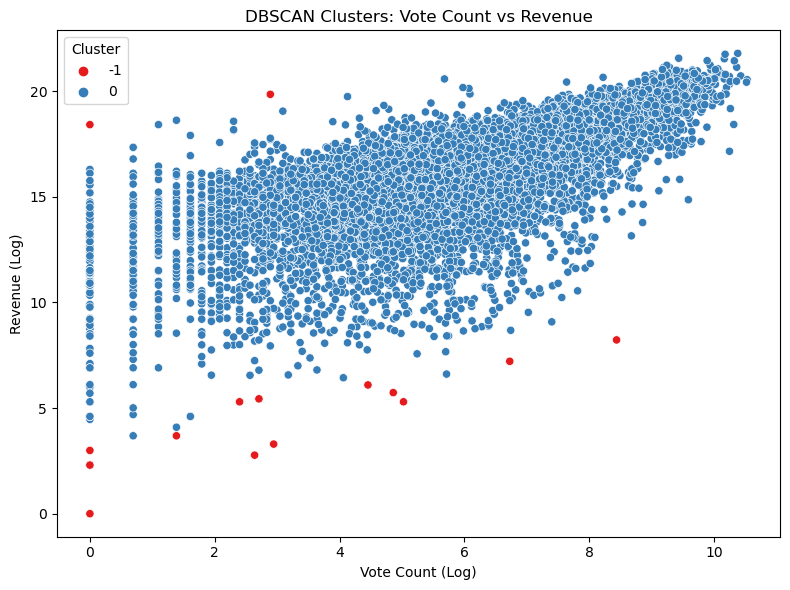

cluster
 0    9937
-1      16
Name: count, dtype: int64


In [203]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X['log_vote_count'], y=X['log_revenue'], hue=df['cluster'], palette='Set1', legend='full')
plt.title('DBSCAN Clusters: Vote Count vs Revenue')
plt.xlabel('Vote Count (Log)')
plt.ylabel('Revenue (Log)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

print(df['cluster'].value_counts())

___
### 💡 Reminder: points considered outliers are classified as -1
___

### 🤔 Initial Clustering Thoughts
- For the initial metrics of epsilon = 0.5 and minimum samples = 10, we gather only 1 main cluster and another "cluster" of outliers (-1).
- The main cluster dominates with nearly all data points and the few outliers surround the main cluster.
- Because we only managed to get one cluster we can't calculate any metric - No real info gained.
- We barely learn any hidden patterns.
   
We will test different epsilon and min_samples metrics to see how this effects the clusters:

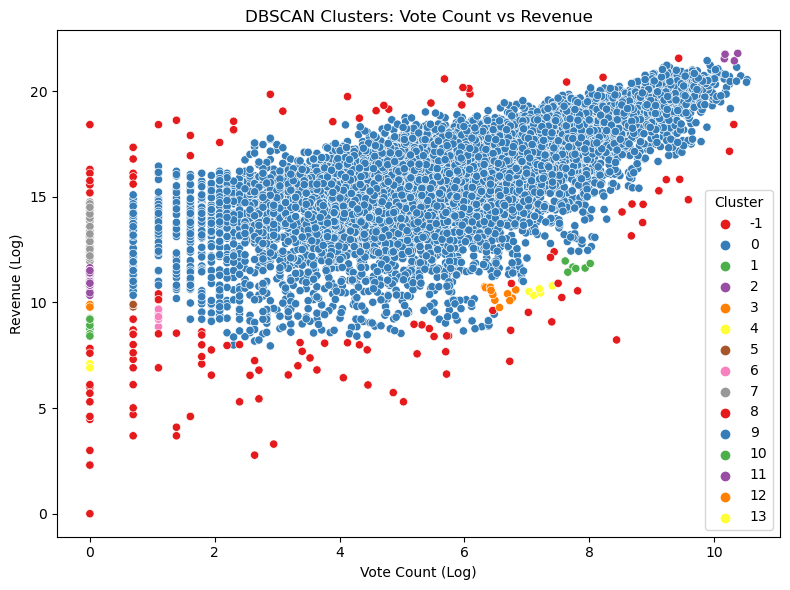

cluster
 0     9631
-1      134
 9       57
 7       37
 11      27
 10      12
 3       11
 6        7
 12       7
 1        6
 4        5
 5        5
 8        5
 13       5
 2        4
Name: count, dtype: int64


In [204]:
dbscan = DBSCAN(eps=0.15, min_samples=5)
df['cluster'] = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X['log_vote_count'], y=X['log_revenue'], hue=df['cluster'], palette='Set1', legend='full')
plt.title('DBSCAN Clusters: Vote Count vs Revenue')
plt.xlabel('Vote Count (Log)')
plt.ylabel('Revenue (Log)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

print(df['cluster'].value_counts())

In [205]:
valid_clusters = df[df["cluster"] != -1]  # Keep only clustered points - Remove noise
X_valid = X_scaled[df["cluster"] != -1]  # Match the filtered dataset

### 🎯 The best suited evaluation metric for DBSCAN is the `Davies-Boulding Index`
- This metric evaluates intra-cluster similarity and inter-cluster differences to give us a score between 0 and ∞.
- The lower the score (closer to 0) the more well-seperated our clusters are.
- Due to it being sensetive to cluster density and shape, it is best tailored to evaluate DBSCAN.

In [206]:
db_score = davies_bouldin_score(X_valid, valid_clusters["cluster"])
print(f"Davies-Bouldin Index: {db_score:.3f}")

Davies-Bouldin Index: 0.662


### 🤔 Secondary Clustering Thoughts
- For the second set of metrics with epsilon = 0.15 and minimum samples = 5, we gather quite a large amount of clusters.
- These clusters are quite well seperated and are fairly compact - as seen both in the plot and with the average DB-Score.
- We learn very little but we do understand the formation of tight data points - such as the purple cluster indicating an extremely high amount of votes that also gained very high revenue.
- Outliers in this case are movies that don't "follow the general correlation pattern".
   
We will test another set of different metrics to see different results:

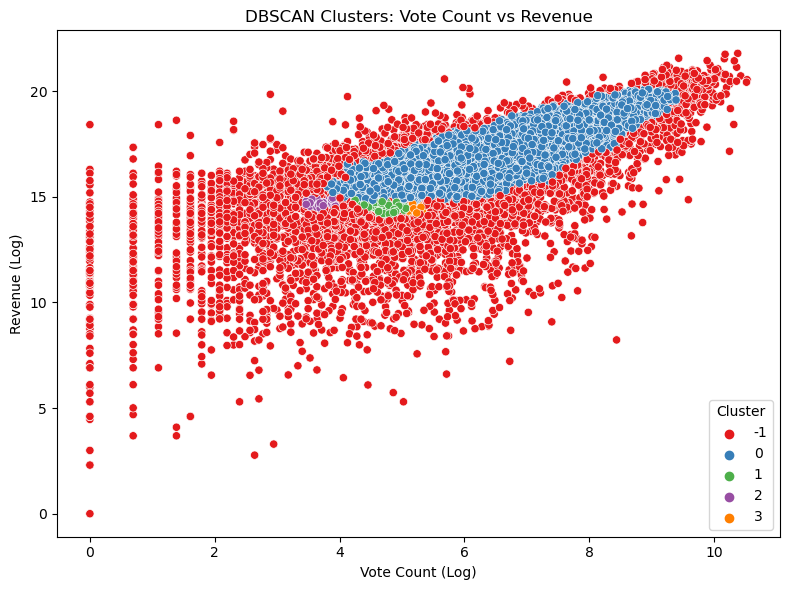

cluster
 0    5684
-1    4026
 1     123
 2      78
 3      42
Name: count, dtype: int64


In [207]:
dbscan = DBSCAN(eps=0.1, min_samples=50)
df['cluster'] = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X['log_vote_count'], y=X['log_revenue'], hue=df['cluster'], palette='Set1', legend='full')
plt.title('DBSCAN Clusters: Vote Count vs Revenue')
plt.xlabel('Vote Count (Log)')
plt.ylabel('Revenue (Log)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

print(df['cluster'].value_counts())

In [208]:
valid_clusters = df[df["cluster"] != -1]
X_valid = X_scaled[df["cluster"] != -1]

db_score = davies_bouldin_score(X_valid, valid_clusters["cluster"])
print(f"Davies-Bouldin Index: {db_score:.3f}")

Davies-Bouldin Index: 0.602


### 🤔 Final Clustering Thoughts
- In this instance, we have 4 main cluster groups, with one being largely domainte and outliers representing a fairly big percentage of the data points.
- The clusters are greatly compact yet sit very close to one another - forcing our DB score not to improve by too much.
- We see that the 3 smaller clusters are seperated due to them having different vote counts on about the same revenue made.
- We can infer that a different contibuting factor is what seperates these clusters and it is an insight that can be made if we further disect this.

### 🔍 Next Step: Understanding the Clusters

With our final clustering results in place, the focus now shifts to **exploring what defines each cluster**.

We'll look into whether these groups share any **common traits or trends**, and see if the separation created by DBSCAN offers **meaningful insights** into the movies.

The goal is to interpret what each cluster might represent — whether it's based on production style, popularity, time period, or other hidden patterns in the data.

In [209]:
cluster_stats = df[df['cluster'].isin([1, 2, 3])].groupby('cluster').agg({
    'budget': ['mean', 'median', 'min', 'max'],
    'release_year': ['mean', 'median', 'min', 'max'],
    'runtime': ['mean', 'median', 'min', 'max'],
    'num_production_countries': ['mean', 'median', 'min', 'max'],
    'num_spoken_languages': ['mean', 'median', 'min', 'max']
}).round(1)

pd.set_option('display.float_format', '{:,.2f}'.format)

print("📊 Cluster-wise statistics for clusters 1, 2, and 3:\n")
cluster_stats

📊 Cluster-wise statistics for clusters 1, 2, and 3:



budget                                release_year           \
                mean       median     min       max         mean   median   
cluster                                                                     
1       6,082,935.30 2,000,000.00    9300  80000000     1,986.10 1,996.00   
2       4,475,729.70 2,038,000.00   82000  36000000     1,987.20 1,996.00   
3       7,245,972.70 4,850,001.00  439000  35000000     1,991.80 2,001.00   

                    runtime                 num_production_countries         \
          min   max    mean median min  max                     mean median   
cluster                                                                       
1        1927  2019  104.10 101.00  66  175                     1.40   1.00   
2        1927  2023  107.90 102.00  74  172                     1.30   1.00   
3        1924  2017  107.30 104.00  76  173                     1.60   1.00   

                num_spoken_languages                 
        min max                 mean median min max  
cluster                                              
1         1   6                 1.40   1.00   1   6  
2         1   4                 1.40   1.00   1   4  
3         1   6                 1.40   1.00   1   5

### 💡 Insight:
We can tell that the main difference that difers between these 3 clusters is the budget.  
Is seems as though the higher the budget the more vote counts we receive for movies that made around the same revenue.  
This is an interesing take that could be used and explored more deeply if wanted.
___

### We will continue to test different features:  
`vote_count`, `vote_average` and `runtime` could raise some interesting insights.  

❗ `vote_count` is very highly skewed so we will need to log transform it.  
❗ Due to `vote_count` having '1' values, we will use log1p() so that the converted vote count will start at 1 and not 0.

In [210]:
df['log_vote_count'] = np.log1p(df['vote_count'])

In [211]:
X = df[['log_vote_count', 'vote_average', 'runtime']]

In [212]:
X_scaled = scaler.fit_transform(X)

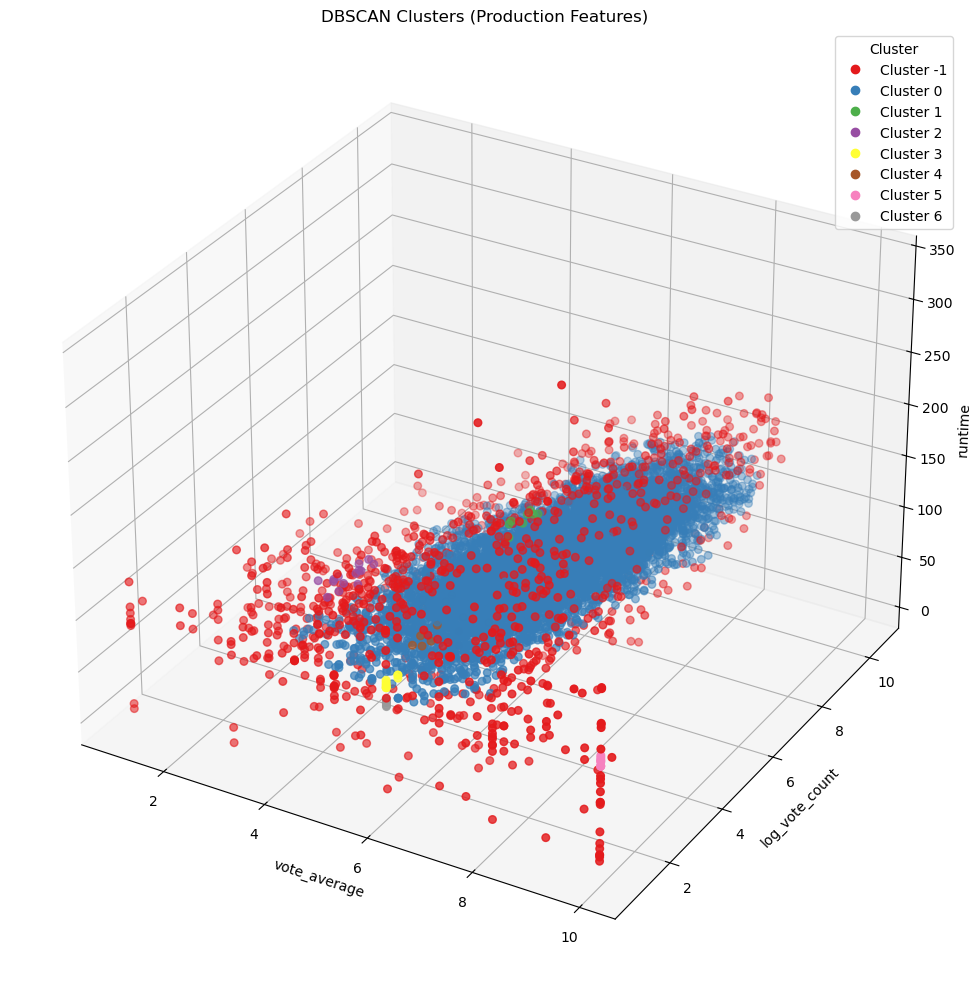

cluster
 0    8922
-1     980
 2      14
 3      10
 1       8
 5       8
 6       6
 4       5
Name: count, dtype: int64


In [213]:
dbscan = DBSCAN(eps=0.3, min_samples=8)
df['cluster'] = dbscan.fit_predict(X_scaled)

x = df['vote_average']
y = df['log_vote_count']
z = df['runtime']
labels = df['cluster']

# Set up 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with cluster hue
scatter = ax.scatter(x, y, z, c=labels, cmap='Set1', s=30)

# Axis labels
ax.set_title('DBSCAN Clusters (Production Features)')
ax.set_xlabel('vote_average')
ax.set_ylabel('log_vote_count')
ax.set_zlabel('runtime')

# Add legend with unique labels
handles, _ = scatter.legend_elements(prop="colors")
cluster_labels = [f'Cluster {label}' for label in sorted(df['cluster'].unique())]
ax.legend(handles, cluster_labels, title="Cluster", loc='upper right')

plt.tight_layout()
plt.show()

# Print cluster counts
print(df['cluster'].value_counts())

### ❓ It is quite challenging to understand the 3D graph but we have options to make insights a bit clearer:
- We can either use PCA or t-SNE to reduce the dimensions to a 2D graph.
- Or we can use the `weighted_rating` feature that consists of both the `vote_average` and the `vote_count` in it's formula.

In [214]:
X = df[['weighted_rating', 'runtime']]

In [215]:
X_scaled = scaler.fit_transform(X)

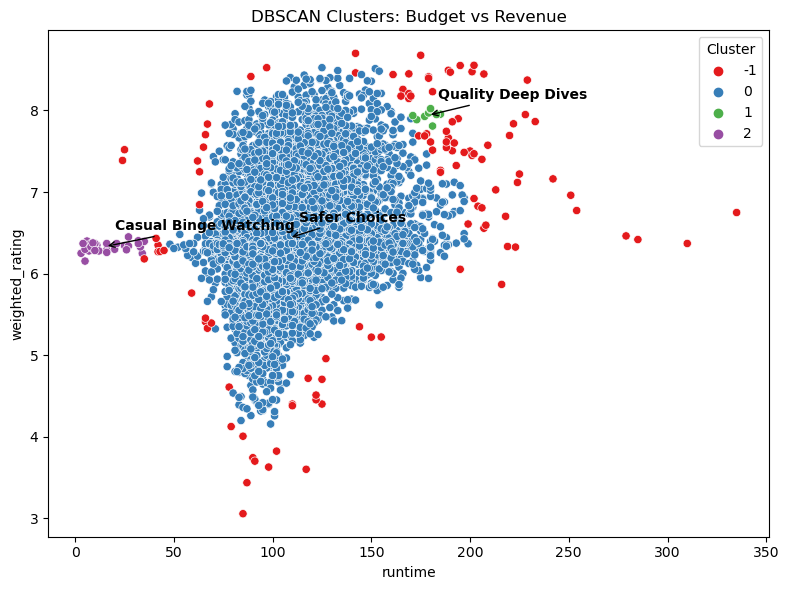

cluster
 0    9800
-1     110
 2      34
 1       9
Name: count, dtype: int64


In [216]:
dbscan = DBSCAN(eps=0.3, min_samples=8)
df['cluster'] = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X['runtime'], y=X['weighted_rating'], hue=df['cluster'], palette='Set1', legend='full')
plt.title('DBSCAN Clusters: Budget vs Revenue')
plt.xlabel('runtime')
plt.ylabel('weighted_rating')
plt.legend(title='Cluster')
plt.tight_layout()


custom_labels = {
    0: "Safer Choices",
    1: "Quality Deep Dives",
    2: "Casual Binge Watching",
}
for cluster_id, label in custom_labels.items():
    if cluster_id not in df['cluster'].unique(): # Skip outlier 'group'
        continue
    cluster_data = df[df['cluster'] == cluster_id]
    center_x = cluster_data['runtime'].mean()
    center_y = cluster_data['weighted_rating'].mean()
    plt.annotate(label,
                 xy=(center_x, center_y),
                 xytext=(center_x + 5, center_y + 0.2),
                 arrowprops=dict(facecolor='black', arrowstyle='->', lw=1),
                 fontsize=10,
                 fontweight='bold',
                 ha='left')

plt.show()

print(df['cluster'].value_counts())

### 💡 After manually testing different combinations of epsilon and minimum values, we gain categorical insights:
- Casual Binge Watching - Movies up to around 50 minutes with average ratings; pass the time movies.
- Safer Choices - Movies of average length with a range of ok ratings; can't go wrong with these.
- Quality Deep Dives - Fairly long movies with high ratings; if you have time to invest in a good watch.

___
### We will try testing another set of features:  
Even though we stated earlier that boolean features are tricky to handle, we would like to see how the different movie `genres` cluster together. 

❗ This will be challenging seeing as there are 19 different genres (columns) - need of dimensionality reduction (we will use PCA).  
❗ Each genre is a binary feature, further making it difficult to interpret (not enough varied info from each feature).  
❗ It will probably not be enformative enough to gain any real conclusions but we will still procceed to check.

In [217]:
print(bool_df.columns.tolist())

['changed_title', 'Comedy', 'Action', 'Animation', 'Drama', 'History', 'Family', 'War', 'Thriller', 'Crime', 'Adventure', 'Music', 'Fantasy', 'Science Fiction', 'TV Movie', 'Western', 'Documentary', 'Romance', 'Mystery', 'Horror', 'top10_prod_comps', 'is_english_spoken']


In [218]:
X = bool_df.drop(columns=['changed_title', 'top10_prod_comps', 'is_english_spoken'])

In [219]:
X_scaled = scaler.fit_transform(X)

### ⏬ PCA - Principal Component Analysis:
- We "trade" information for reduced dimensions.
- The variance ratio will show us how much explained variance we keep when reducing to 'n' components (dimensions).
- We can see how each feature "contributes" to each dimension (after reduction) using either a weighted feature graph or use creative arrows (biplot-style loadings).

### 👍 Rule of Thumb - we should save at least 70-80% of the info variance.

In [220]:
pca = PCA()
pca.fit(X_scaled)

PCA()

In [221]:
pca.explained_variance_ratio_

array([0.12247887, 0.10969036, 0.07990978, 0.06711589, 0.06542673,
       0.05874519, 0.05389689, 0.05232102, 0.05066398, 0.04677809,
       0.04430905, 0.04238245, 0.03923375, 0.03659542, 0.03335441,
       0.02846003, 0.02624514, 0.02338951, 0.01900343])

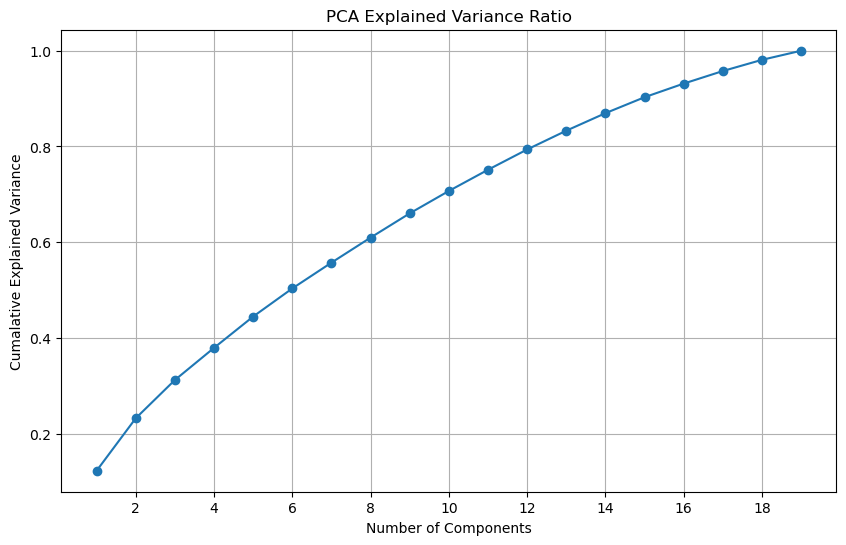

In [222]:
plt.figure(figsize=(10, 6))
plt.plot(range(1,20), pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xticks(range(2, 20, 2))
plt.title('PCA Explained Variance Ratio')
plt.xlabel('Number of Components')
plt.ylabel('Cumalative Explained Variance')
plt.grid(True)
plt.show()

## ❗ Very low info variance is kept at visually explainable dimensions (1/2/3).
   - ❌ We won't be able to come to any real statistical conclusions with this because they only covers around 20-30% of the actual information. 
   - ❌ We can only use this to spot broad patterns, clusters and outliers.

In [223]:
# testing with 3 components ~ 30% explained variance
pca = PCA(n_components=3)
scores_pca = pca.fit_transform(X_scaled)

In [224]:
pca.explained_variance_ratio_

array([0.12247671, 0.10968777, 0.07980786])

In [225]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(scores_pca)

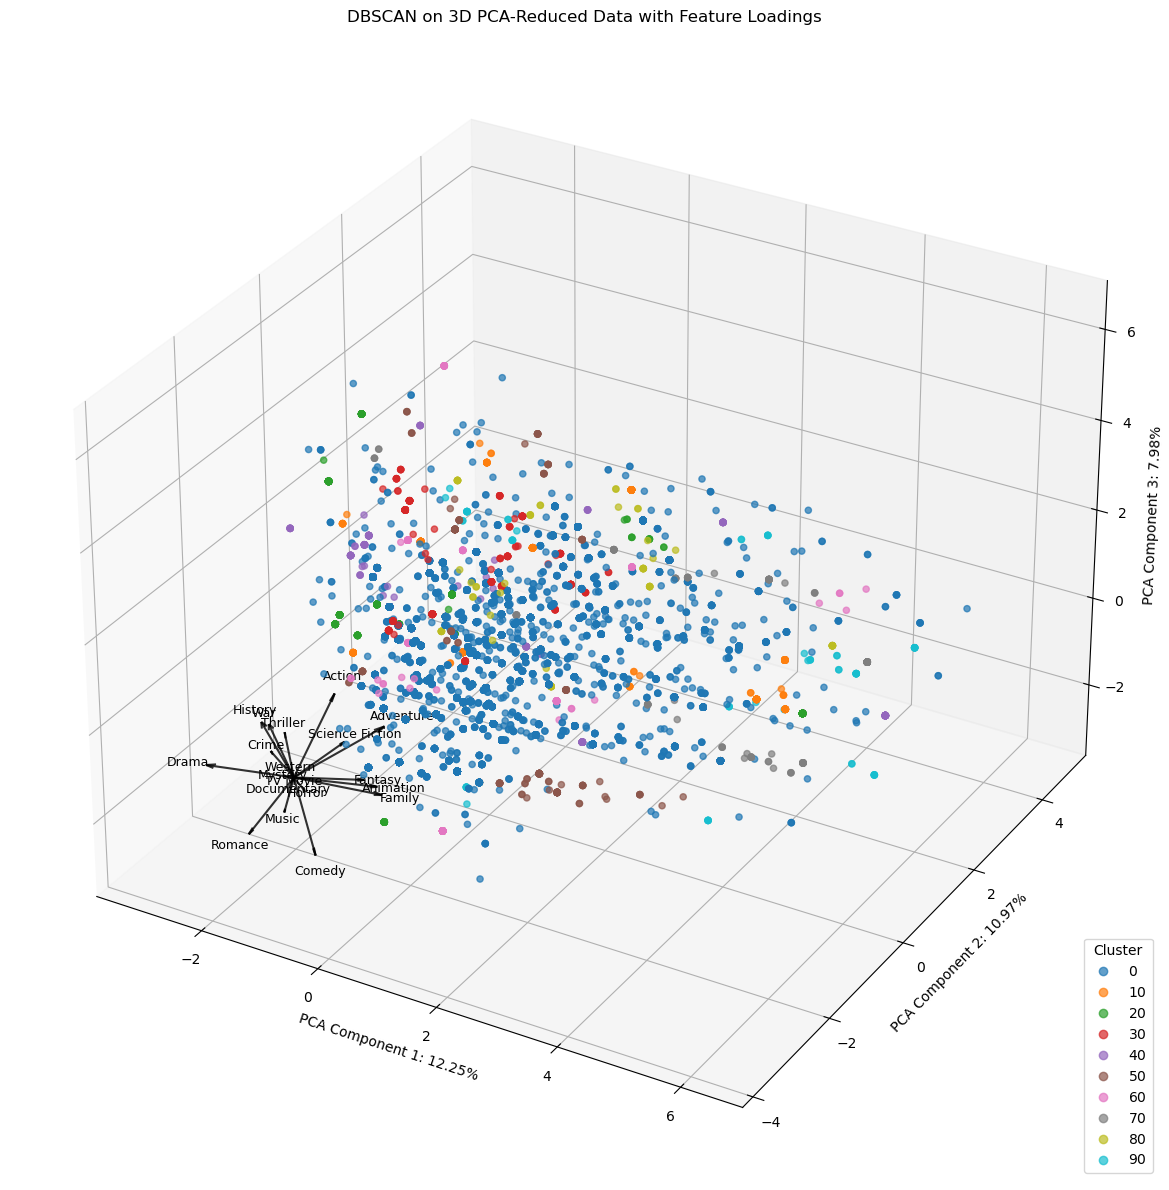

In [226]:
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(scores_pca[:, 0], scores_pca[:, 1], scores_pca[:, 2],
                     c=labels, cmap='tab10', alpha=0.7)

ax.set_xlabel(f'PCA Component 1: {pca.explained_variance_ratio_[0] * 100:.2f}%')
ax.set_ylabel(f'PCA Component 2: {pca.explained_variance_ratio_[1] * 100:.2f}%')
ax.set_zlabel(f'PCA Component 3: {pca.explained_variance_ratio_[2] * 100:.2f}%')
ax.set_title('DBSCAN on 3D PCA-Reduced Data with Feature Loadings')
ax.legend(*scatter.legend_elements(), title="Cluster", loc='lower right')

# Offset origin
offset = -2
arrow_size = 3
feature_names = X.columns

# Draw arrows from offset point
for i in range(pca.components_.shape[1]):
    ax.quiver(offset, offset, offset,
              pca.components_[0, i] * arrow_size,
              pca.components_[1, i] * arrow_size,
              pca.components_[2, i] * arrow_size,
              color='black', arrow_length_ratio=0.1, alpha=0.8)

    ax.text(offset + pca.components_[0, i] * arrow_size * 1.2,
            offset + pca.components_[1, i] * arrow_size * 1.2,
            offset + pca.components_[2, i] * arrow_size * 1.2,
            feature_names[i],
            color='black', fontsize=9, ha='center', va='center')

plt.tight_layout()
plt.show()

In [227]:
# testing with 2 components ~ 20% explained variance
pca = PCA(n_components=2)
scores_pca = pca.fit_transform(X_scaled)

In [228]:
pca.explained_variance_ratio_

array([0.12247813, 0.10968813])

In [229]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(scores_pca)

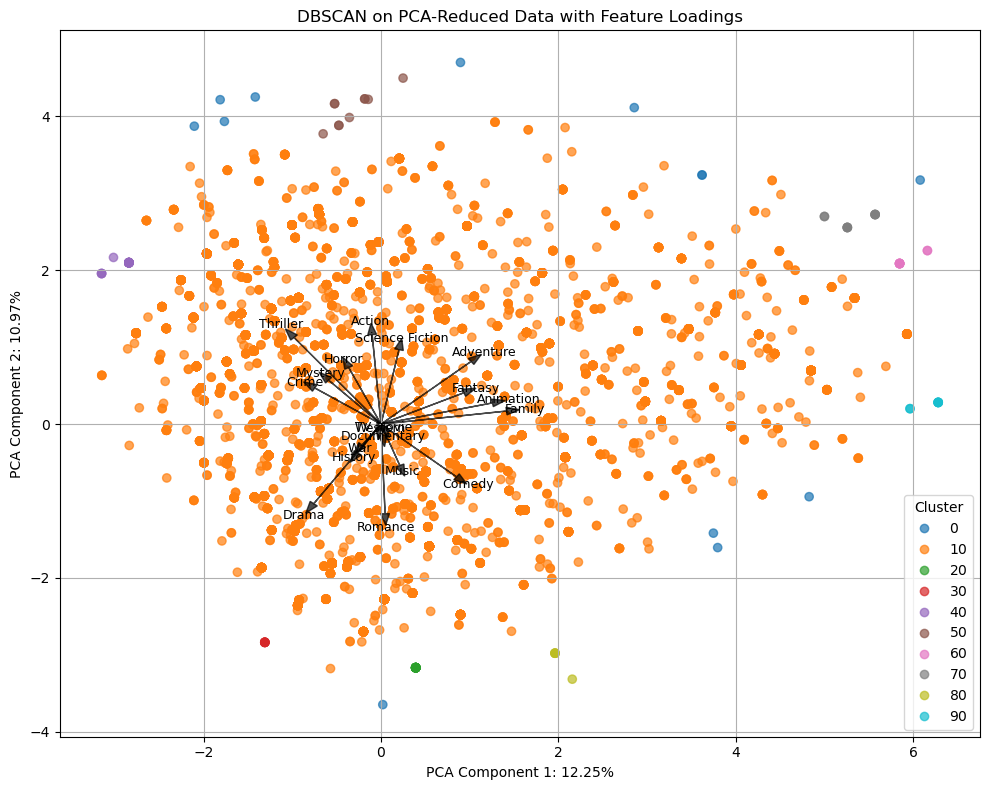

In [230]:
plt.figure(figsize=(10, 8))
plt.scatter(scores_pca[:, 0], scores_pca[:, 1], c=labels, cmap='tab10', alpha=0.7)
plt.xlabel(f'PCA Component 1: {pca.explained_variance_ratio_[0] * 100:.2f}%')
plt.ylabel(f'PCA Component 2: {pca.explained_variance_ratio_[1] * 100:.2f}%')
plt.title('DBSCAN on PCA-Reduced Data with Feature Loadings')
plt.legend(*scatter.legend_elements(), title="Cluster", loc='lower right')
plt.grid(True)

# Add PCA component vectors ("arrows")
arrow_size = 3  
feature_names = X.columns 
for i in range(pca.components_.shape[1]):
    plt.arrow(0, 0,
              pca.components_[0, i] * arrow_size,
              pca.components_[1, i] * arrow_size,
              color='black', alpha=0.7, head_width=0.1)
    plt.text(pca.components_[0, i] * arrow_size * 1.15,
             pca.components_[1, i] * arrow_size * 1.15,
             feature_names[i],
             color='black', ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### ⏬ t-SNE - t-distributed Stochastic Neighbor Embedding:
- Unlike PCA, t-SNE is a non-linear technique that focuses on keeping the local structure of the data - points that are close in high dimension will stay close in low dimensions.
- Uses a t-distribution to model the probability of points being neighbors.
- A key parameter in t-SNE is `perplexity`, which controls the number of nearest neighbors considered when calculating the probability distributions:  
    * A lower perplexity focuses on local structure.  
    * A higher perplexity considers more global relationships.

### 🫡 t-SNE tends to pair better with DBSCAN since both focus on preserving local neighborhood structure and density-based relationships.
### 🚨 Important Note - t-SNE is not ment to interpret feature contibution but rather visualize how the data is structured.

In [231]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=3, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

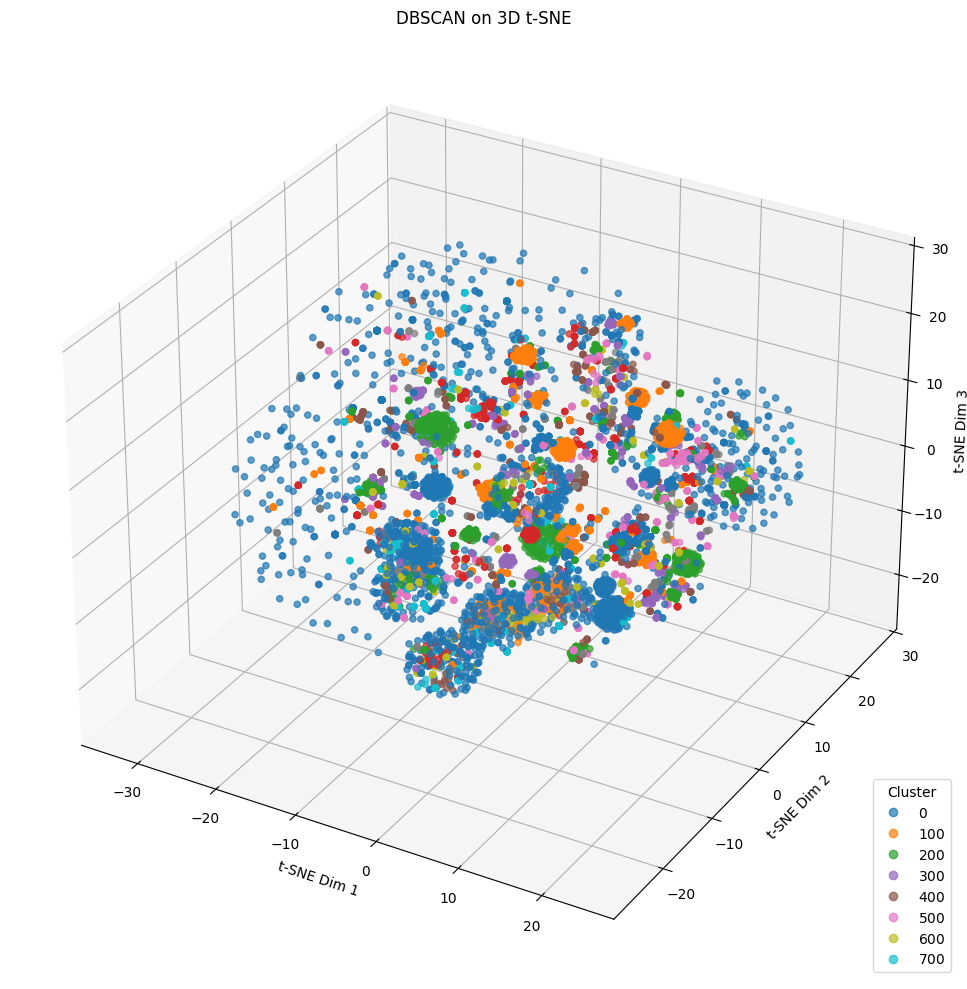

In [543]:
dbscan = DBSCAN(eps=0.9, min_samples=3)
labels = dbscan.fit_predict(X_tsne)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2],
                     c=labels, cmap='tab10', alpha=0.7)

ax.set_xlabel('t-SNE Dim 1')
ax.set_ylabel('t-SNE Dim 2')
ax.set_zlabel('t-SNE Dim 3')
ax.set_title('DBSCAN on 3D t-SNE')
ax.legend(*scatter.legend_elements(), title="Cluster", loc='lower right')
plt.tight_layout()
plt.show()

### 💡 After manually testing different combinations of epsilon and minimum values, we can see patterns in the data:
- We can see round structers of data form, probably representing each individual genre.
- Different clusters may represent common/dominate genre combinations.
- The main cluster (0) dominates the space, which could mean that it's points are densely packed in high-dimensional space but not distinctive enough to be separated into meaningful clusters by DBSCAN.

___
### Finally, we will test a last group of features:  
`num_production_companies`, `num_production_countries` and `num_spoken_languages` could raise some interesting insights.  

❗ All 3 features are highly skewed and so we will need to log transform them.  
❗ Because `num_production_companies`, `num_production_countries` are fairly correlated, their distances maybe biased - pay attention.  
❗ `num_production_companies` can have a value of 0.

Due to one feature having a value of 0, regular log transform won't work.  
We will need to use log1p() which does log (x + 1).  
To keep consistency, we will use log1p() on all 3 features even though there is a difference between it and regular log for large values but it is minor. 

In [232]:
df['log_num_production_companies'] = np.log1p(df['num_production_companies'])
df['log_num_production_countries'] = np.log1p(df['num_production_countries'])
df['log_num_spoken_languages'] = np.log1p(df['num_spoken_languages'])

In [233]:
X = df[['log_num_production_companies', 'log_num_production_countries', 'log_num_spoken_languages']]

In [234]:
X_scaled = scaler.fit_transform(X)

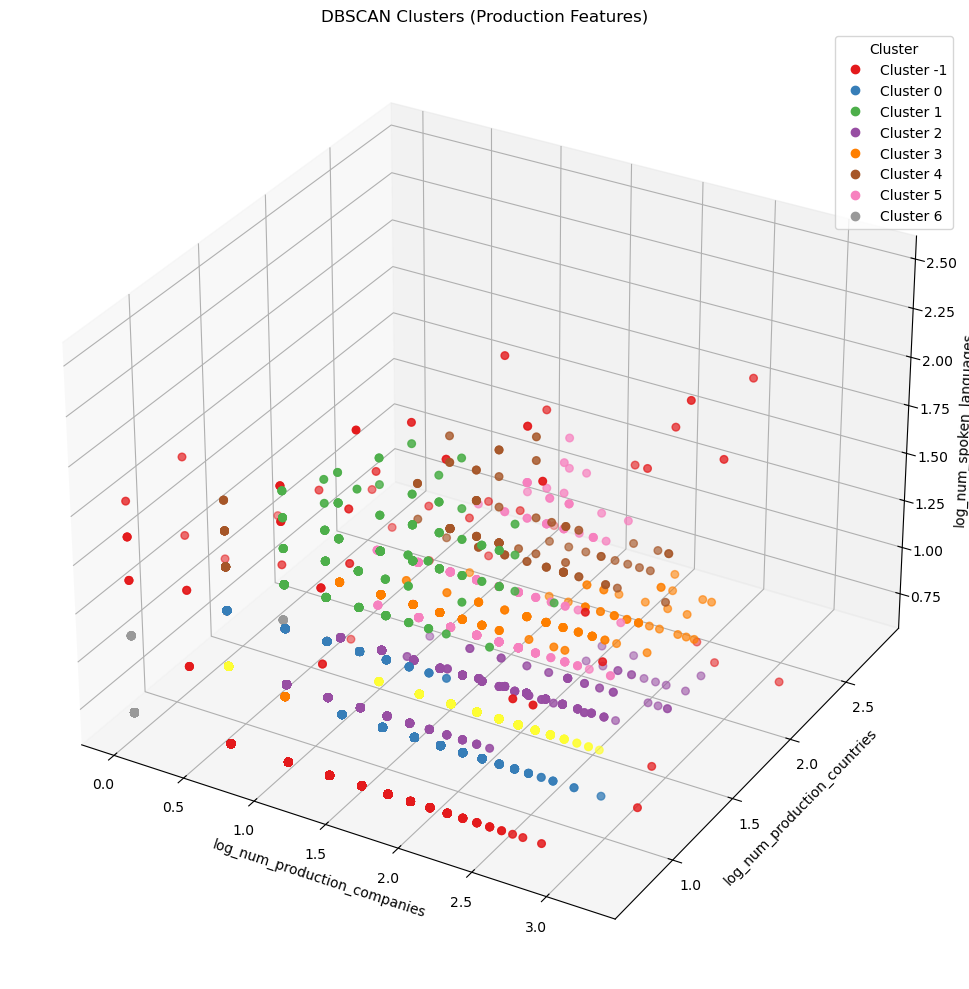

cluster
 0     3688
 1     1672
 3     1056
 9      845
 14     339
 8      323
 13     307
 4      271
 6      169
 7      157
 12     149
 19     148
 22     126
 5      112
 10      92
 20      81
 2       74
-1       74
 11      65
 17      52
 15      41
 16      38
 18      36
 21      19
 23      19
Name: count, dtype: int64


In [235]:
dbscan = DBSCAN(eps=0.7, min_samples=8)
df['cluster'] = dbscan.fit_predict(X_scaled)

x = df['log_num_production_companies']
y = df['log_num_production_countries']
z = df['log_num_spoken_languages']
labels = df['cluster']

# Set up 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with cluster hue
scatter = ax.scatter(x, y, z, c=labels, cmap='Set1', s=30)

# Axis labels
ax.set_title('DBSCAN Clusters (Production Features)')
ax.set_xlabel('log_num_production_companies')
ax.set_ylabel('log_num_production_countries')
ax.set_zlabel('log_num_spoken_languages')

# Add legend with unique labels
handles, _ = scatter.legend_elements(prop="colors")
cluster_labels = [f'Cluster {label}' for label in sorted(df['cluster'].unique())]
ax.legend(handles, cluster_labels, title="Cluster", loc='upper right')

plt.tight_layout()
plt.show()

# Print cluster counts
print(df['cluster'].value_counts())

### 💡 After manually testing different combinations of epsilon and minimum values, we see patterns in the data:
  
- Even though it is quite difficult to see exactly the different data points in the 3D graph, we do see "line clusters" form across the y-axis.
- This means that the points cluster based on the number of production countries.
- We can interpret this to say that movies are more densely crowded according to this metric than the others because of DBSCAN's way of clustering.
- We might be able to better understand this if we reduce out dimensions and plot them on a 2D graph using PCA.

In [236]:
# reducing to 2 components ~ 83% explained variance
pca = PCA(n_components=2)
scores_pca = pca.fit_transform(X_scaled)

pca.explained_variance_ratio_

array([0.53713686, 0.30025442])

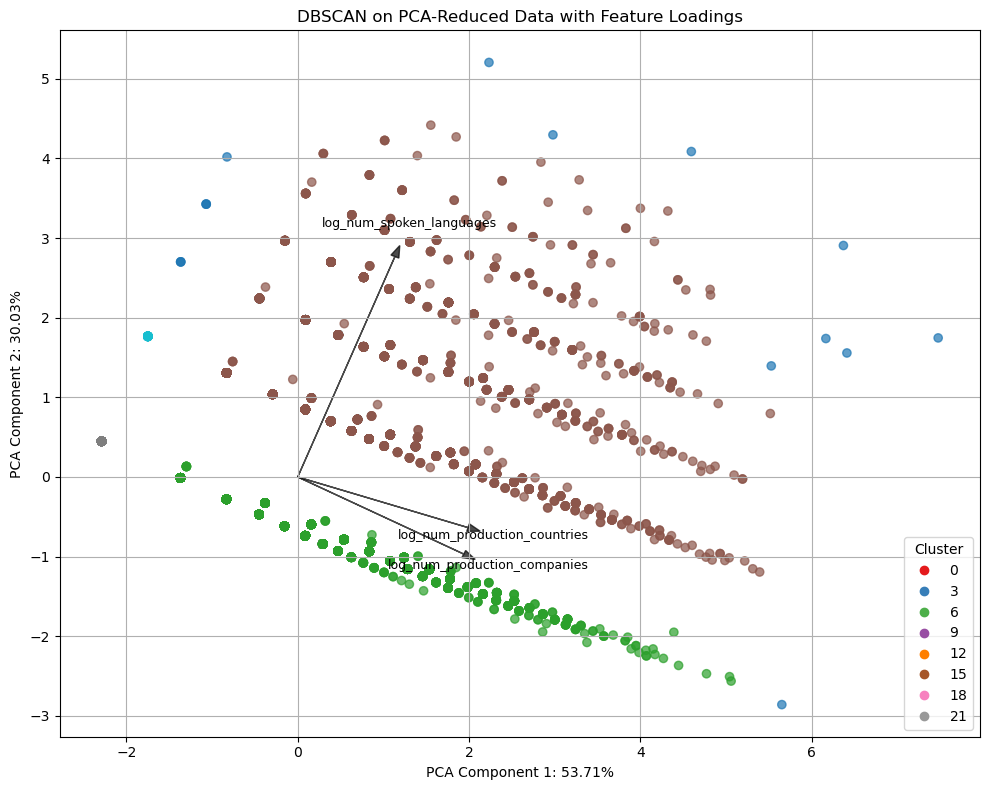

In [237]:
dbscan = DBSCAN(eps=0.7, min_samples=8)
labels = dbscan.fit_predict(scores_pca)

plt.figure(figsize=(10, 8))
plt.scatter(scores_pca[:, 0], scores_pca[:, 1], c=labels, cmap='tab10', alpha=0.7)
plt.xlabel(f'PCA Component 1: {pca.explained_variance_ratio_[0] * 100:.2f}%')
plt.ylabel(f'PCA Component 2: {pca.explained_variance_ratio_[1] * 100:.2f}%')
plt.title('DBSCAN on PCA-Reduced Data with Feature Loadings')
plt.legend(*scatter.legend_elements(), title="Cluster", loc='lower right')
plt.grid(True)

# Add PCA component vectors ("arrows")
arrow_size = 3  
feature_names = X.columns 
for i in range(pca.components_.shape[1]):
    plt.arrow(0, 0,
              pca.components_[0, i] * arrow_size,
              pca.components_[1, i] * arrow_size,
              color='black', alpha=0.7, head_width=0.1)
    plt.text(pca.components_[0, i] * arrow_size * 1.15,
             pca.components_[1, i] * arrow_size * 1.15,
             feature_names[i],
             color='black', ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 🤔 Thoughts
- Using the same metrics, the clusters have changed due to the dimension reduction.
- This is because when we reduce features, the computative distance where a point is placed is differently calculated and so points are distibuted differently.
- We can try testing different metric combinations to try and "re-create" as close as possible the cluster arrangment from before the PCA reduction or we can learn different things from this distribution instead.
- Due to the first option not being very practical, we will try to understand what we can from this form of clustering:
   * Even though we reduced 3 dimensions to 2, we still see that one feature dominates one axis (with a slight angle) and the other 2 concentrate on the other axis.
   * These formed 'layers' represent the number of spoken languages quite clearly.
   * DBSCAN has clustered nearly all movies with only 1 spoken language together whilst movies with more than 1 are generally all together.
   * The other clusters are similar to outliers in the sense that they don't represent the general spread of movies but compact together to form proper clusters.

___

<h1 style="text-align:center;font-size:300%;font-family:verdana; font-weight:bold;">
Conclusions
</h1>


##### 📌 Project Overview
This notebook explored clustering movie data using the DBSCAN algorithm — a powerful density-based method capable of identifying clusters of arbitrary shape and detecting outliers. It was applied to thousands of TMDb movie records, aiming to uncover natural groupings in a high-dimensional dataset of features such as revenue, popularity, spoken languages, and more.

---

### 📊 Clustering Attempts and Observations:

1. **💰 Vote Count vs Revenue**:
   - Both features were highly correlated, leading us to check them seperately.
   - We applyed log transformations, due to them both being highly skewed.
   - Initial clustering attempts with these features yielded a dominant single cluster and a few outliers.
   - Futher hyper-parameter tunings led to differret clusters and better interpretability.
   - We gained an insight - movies that record around the same amount of revenue have different amount of votes largely due to different budgets.
   - This can indicate that higher budgeting leads to more exposure and further drives audience to vote for the movie. 

2. **🎞️ Weighted Rating vs Runtime**:
   - These features produced more catagorical type clusters.
   - Runtime helped distinguish between short-form content and full-length films, while weighted rating provided quality-related differentiation.
   - Outliers identified through this setup often reflected movies that don't follow the trends we catagorized.

3. **🎭 Genre Distribution**:
   - Using binary genre indicators (e.g., Action, Comedy) proved ineffective with DBSCAN due to many dimensions as well as distance metric limitations.
   - The use of PCA didn't provide helpful because of the very limited info gain that each binary feature offers.
   - After trying t-SNE we managed to see a rough visual of the genre groupings but no real insights could be drawn.

4. **🌍 Languages, Countries and Companies**:
   - Clustering on `log_num_production_companies`, `log_num_production_countries`, and `log_num_spoken_languages` led to feature dominate clustering.
   - The 3D plot showed vague cluster formation, indicating that the clusters form mainly by numbe of production companies.
   - When plotting on a 2D graph, clustering changed due to the different distance calculations applied on lesser dimensions.
   - Unfortunately no real insights could be gathered.

---

### What we learned about DBSCAN:

- Feature selection and preprocessing (especially log transformation and scaling) play a critical role in DBSCAN’s performance.
- Clustering results are highly sensitive to hyperparameters (`eps`, `min_samples`), and tuning them is essential to extract meaningful insights.
- The best outcomes were observed when focusing on production-related features and avoiding sparse binary variables, highlighting the importance of carefully selecting clustering inputs.